# Semana 1 — Exploración y Análisis Exploratorio de Datos (EDA)

**Dataset:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe, 2000–2022  
**Fuente:** CEPALSTAT — Comisión Económica para América Latina y el Caribe (CEPAL / Naciones Unidas)  
**Archivo original:** `data/data_1777144519.xlsx`

## 1. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

EXCEL_PATH = 'data/data_1777144519.xlsx'
CSV_PATH   = 'data/datos.csv'

## 2. Exploración del archivo Excel

El archivo Excel original contiene **cinco hojas** que fueron exportadas individualmente como archivos CSV en la carpeta `data/`.

| Hoja | CSV exportado | Contenido |
|------|---------------|-----------|
| datos | `datos.csv` | Serie de tiempo principal (870 filas) |
| metadatos | `metadatos.csv` | Descripción del indicador, metodología, unidades |
| fuentes | `fuentes.csv` | Organización fuente (CEPAL) |
| notas | `notas.csv` | Notas aclaratorias (vacío en este dataset) |
| creditos | `creditos.csv` | Créditos y fecha de descarga |

In [2]:
# Listar hojas del Excel
xls = pd.ExcelFile(EXCEL_PATH, engine='openpyxl')
print('Hojas encontradas en el Excel:')
for nombre in xls.sheet_names:
    print(f'  • {nombre}')

Hojas encontradas en el Excel:
  • datos
  • metadatos
  • fuentes
  • notas
  • creditos


In [3]:
# Vista rápida de cada hoja (primeras 3 filas)
for nombre in xls.sheet_names:
    df_hoja = xls.parse(nombre)
    print(f'\n--- Hoja: {nombre} ({df_hoja.shape[0]} filas x {df_hoja.shape[1]} columnas) ---')
    display(df_hoja.head(3))


--- Hoja: datos (870 filas x 8 columnas) ---


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2016,75.9,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
1,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2017,75.9,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
2,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2018,78.5,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353



--- Hoja: metadatos (12 filas x 2 columnas) ---


,metadata,value
0,indicator_id,4987
1,indicator_name,"Personas usuarias de Internet por grupo etario, países seleccionados América..."
2,theme,Tecnologías de Información y Comunicación



--- Hoja: fuentes (1 filas x 6 columnas) ---


,id,organization_name,description,organization_url,organization_acronym,publication_url
0,9353,Comisión Económica para América Latina y el Caribe,Observatorio de Desarrollo Digital (ODD) sobre la base del Banco de Encuesta...,http://www.eclac.org/,CEPAL,NaN



--- Hoja: notas (0 filas x 1 columnas) ---


,id



--- Hoja: creditos (4 filas x 2 columnas) ---


,id,description
0,0,2026-04-25
1,1,CEPALSTAT
2,2,Comisión Económica para América Latina y el Caribe – CEPAL


## 3. Carga del dataset principal (`datos.csv`)

El archivo usa separador **punto y coma (`;`)** y codificación **Latin-1** (caracteres españoles como tildes y ñ).

In [4]:
df = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones: 870 filas x 8 columnas


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2016,76,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
1,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2017,76,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
2,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2018,79,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
3,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2019,79,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353
4,"Personas usuarias de Internet por grupo etario, países seleccionados América...",Argentina,edad de medicion a 17 años,2020,88,Porcentaje sobre el total de personas en cada grupo etario,NaN,9353


In [5]:
df.dtypes

indicator                          str
País__ESTANDAR                     str
Grupos etarios Uso Internet        str
Años__ESTANDAR                   int64
value                            int64
unit                               str
notes_ids                      float64
source_id                        int64
dtype: object

## 4. Análisis de columnas

Cada fila representa la **tasa de uso de Internet** (%) para una combinación única de: país + grupo etario + año.

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `indicator` | str | Nombre completo del indicador (constante en todo el dataset) |
| `País__ESTANDAR` | str | Nombre estandarizado del país |
| `Grupos etarios Uso Internet` | str | Grupo de edad de los usuarios |
| `Años__ESTANDAR` | int | Año de la medición |
| `value` | int/float | Porcentaje de personas usuarias de Internet en ese grupo |
| `unit` | str | Unidad (constante: porcentaje sobre total del grupo) |
| `notes_ids` | float | ID de nota aclaratoria (mayormente vacío) |
| `source_id` | int | ID de la fuente (9353 = CEPAL) |

In [6]:
# Columnas con valor constante (no aportan variabilidad)
for col in ['indicator', 'unit', 'source_id']:
    vals = df[col].unique()
    print(f'{col} ({len(vals)} valor único): {vals}')

indicator (1 valor único): <StringArray>
['Personas usuarias de Internet por grupo etario, países seleccionados América Latina y el Caribe, 2000 a 2022']
Length: 1, dtype: str
unit (1 valor único): <StringArray>
['Porcentaje sobre el total de personas en cada grupo etario']
Length: 1, dtype: str
source_id (1 valor único): [9353]


In [7]:
# Estadísticas descriptivas de la columna value
df['value'].describe().round(2)

count    870.00
mean      44.86
std       27.81
min        0.00
25%       19.25
50%       45.00
75%       69.00
max       97.00
Name: value, dtype: float64

## 5. Países incluidos

In [8]:
paises = sorted(df['País__ESTANDAR'].unique())
print(f'Total de países: {len(paises)}\n')
for p in paises:
    print(f'  • {p}')

Total de países: 14

  • Argentina
  • Bolivia (Estado Plurinacional de)
  • Brasil
  • Chile
  • Colombia
  • Costa Rica
  • Ecuador
  • El Salvador
  • Honduras
  • México
  • Panamá
  • Paraguay
  • Perú
  • Uruguay


In [9]:
# Número de registros por país
df.groupby('País__ESTANDAR').size().sort_values(ascending=False).rename('n_registros')

País__ESTANDAR
Paraguay                             102
Perú                                  96
Honduras                              72
El Salvador                           72
Uruguay                               72
Bolivia (Estado Plurinacional de)     66
Colombia                              60
Costa Rica                            54
Chile                                 48
Brasil                                48
México                                48
Ecuador                               48
Argentina                             42
Panamá                                42
Name: n_registros, dtype: int64

## 6. Años disponibles

In [10]:
anios = sorted(df['Años__ESTANDAR'].unique())
print(f'Rango general: {min(anios)} – {max(anios)}')
print(f'Total de años distintos en el dataset: {len(anios)}')
print(f'Años: {anios}')

Rango general: 2000 – 2022
Total de años distintos en el dataset: 21
Años: [np.int64(2000), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [11]:
# Cobertura temporal por país (año mínimo y máximo con datos)
cobertura = df.groupby('País__ESTANDAR')['Años__ESTANDAR'].agg(['min', 'max', 'count'])
cobertura.columns = ['año_inicio', 'año_fin', 'n_registros']
cobertura.sort_values('año_inicio')

,año_inicio,año_fin,n_registros
País__ESTANDAR,,,
Chile,2000,2017,48
Honduras,2004,2019,72
Paraguay,2005,2022,102
Brasil,2005,2015,48
El Salvador,2006,2019,72
Perú,2007,2022,96
Uruguay,2008,2019,72
Bolivia (Estado Plurinacional de),2009,2021,66
Ecuador,2009,2019,48


> **Observación:** La cobertura temporal **no es uniforme** entre países. Algunos países tienen datos desde 2006–2008, mientras que otros solo desde 2009 o 2012. El año de corte también varía: Argentina llega a 2022 y Uruguay solo a 2019.

## 7. Grupos etarios

In [12]:
grupos = sorted(df['Grupos etarios Uso Internet'].unique())
print(f'Total de categorías: {len(grupos)}\n')
for g in grupos:
    print(f'  • {g}')

Total de categorías: 6

  • 18 a 25 años de edad
  • 26 a 50 años de edad
  • 51 a 65 años
  • 66 años en adelante
  • Total
  • edad de medicion a 17 años


In [13]:
# Valor promedio de uso de Internet por grupo etario (todos los países y años)
df.groupby('Grupos etarios Uso Internet')['value'].mean().round(1).sort_values(ascending=False)

Grupos etarios Uso Internet
18 a 25 años de edad          66.9
edad de medicion a 17 años    54.3
26 a 50 años de edad          52.0
Total                         48.4
51 a 65 años                  33.0
66 años en adelante           14.5
Name: value, dtype: float64

> **Nota:** El grupo **"Total"** es un agregado poblacional calculado sobre todos los grupos etarios. No es un grupo etario real; en el análisis predictivo deberá separarse del resto.

## 8. Calidad de datos y valores faltantes

In [14]:
# Valores nulos por columna
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulos, 'porcentaje (%)': pct})

,nulos,porcentaje (%)
indicator,0,0.0
País__ESTANDAR,0,0.0
Grupos etarios Uso Internet,0,0.0
Años__ESTANDAR,0,0.0
value,0,0.0
unit,0,0.0
notes_ids,870,100.0
source_id,0,0.0


In [15]:
# Combinaciones país-año-grupo sin dato (panel incompleto)
pivot = df[df['Grupos etarios Uso Internet'] != 'Total'].pivot_table(
    index=['País__ESTANDAR', 'Años__ESTANDAR'],
    columns='Grupos etarios Uso Internet',
    values='value'
)
filas_incompletas = pivot[pivot.isnull().any(axis=1)]
print(f'Combinaciones país-año con al menos un grupo faltante: {len(filas_incompletas)}')

Combinaciones país-año con al menos un grupo faltante: 0


## 9. Distribución de valores

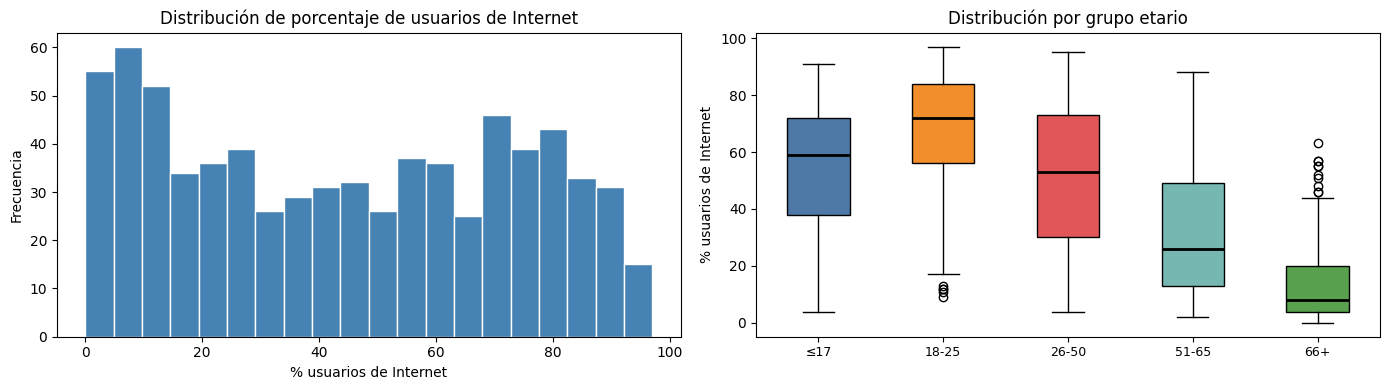

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma general
df_grupos = df[df['Grupos etarios Uso Internet'] != 'Total']
axes[0].hist(df_grupos['value'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de porcentaje de usuarios de Internet')
axes[0].set_xlabel('% usuarios de Internet')
axes[0].set_ylabel('Frecuencia')

# Boxplot por grupo etario
grupos_orden = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante'
]
data_box = [df[df['Grupos etarios Uso Internet'] == g]['value'].dropna().values for g in grupos_orden]
bp = axes[1].boxplot(data_box, patch_artist=True, medianprops=dict(color='black', linewidth=2))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_xticklabels(['≤17', '18-25', '26-50', '51-65', '66+'], fontsize=9)
axes[1].set_title('Distribución por grupo etario')
axes[1].set_ylabel('% usuarios de Internet')

plt.tight_layout()
plt.savefig('data/fig_distribucion_valores.png', dpi=120, bbox_inches='tight')
plt.show()

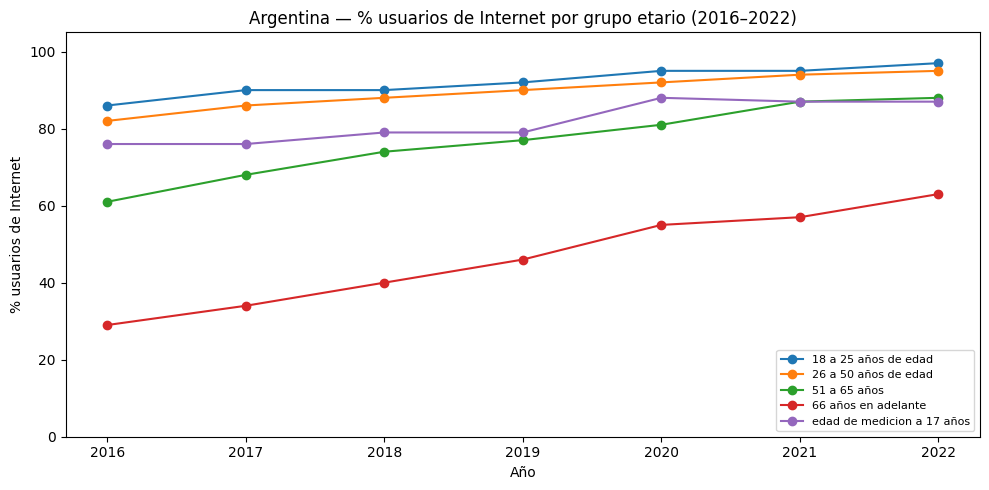

In [17]:
# Evolución temporal de Argentina como ejemplo
arg = df[(df['País__ESTANDAR'] == 'Argentina') & (df['Grupos etarios Uso Internet'] != 'Total')]

fig, ax = plt.subplots(figsize=(10, 5))
for grupo, sub in arg.groupby('Grupos etarios Uso Internet'):
    sub_sorted = sub.sort_values('Años__ESTANDAR')
    ax.plot(sub_sorted['Años__ESTANDAR'], sub_sorted['value'], marker='o', label=grupo)

ax.set_title('Argentina — % usuarios de Internet por grupo etario (2016–2022)')
ax.set_xlabel('Año')
ax.set_ylabel('% usuarios de Internet')
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('data/fig_argentina_tendencia.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Por qué el dataset no está listo directamente para Machine Learning

### Problemas estructurales

1. **Formato largo (long format):** cada fila es una sola observación (país + grupo etario + año → valor). Para ML supervisado, cada instancia debería ser una unidad de análisis completa (ej. un país-año con todos sus grupos como columnas).

2. **Cobertura temporal desigual:** no todos los países tienen datos en los mismos años. Esto genera un **panel desbalanceado** que complica la comparación directa y la construcción de ventanas temporales para predicción.

3. **Columnas constantes/redundantes:** `indicator`, `unit` y `source_id` tienen un solo valor en todo el dataset y deben eliminarse antes de modelar.

4. **Variables categóricas sin codificar:** `País__ESTANDAR` y `Grupos etarios Uso Internet` son texto libre y necesitan encoding (label encoding, one-hot, o embeddings según el modelo).

5. **La fila "Total" mezcla niveles:** el grupo `Total` no es un grupo etario real, sino un agregado. Debe separarse o eliminarse según el objetivo del modelo.

6. **Sin variable objetivo definida:** no hay columna que indique qué se quiere predecir. Hay que decidir si la tarea es predecir el valor de un año futuro, clasificar nivel de adopción, o comparar países.

### Transformaciones necesarias antes de modelar

- Pivotar de formato largo a ancho (pivot: grupos etarios como columnas)
- Seleccionar o imputar años con cobertura completa
- Codificar variables categóricas
- Eliminar columnas redundantes
- Definir la variable objetivo y el horizonte de predicción